In [127]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb

df = pd.read_csv('../zillow_data/stratified_properties_2016.csv',
                 dtype={'airconditioningtypeid': 'object',
                        'basementsqft': 'int64',
                        'bathroomcnt': 'float64',
                        'bedroomcnt': 'int64',
                        'decktypeid': 'object',
                        'calculatedfinishedsquarefeet': 'int64',
                        'fips': 'object',
                        'fireplacecnt': 'object',
                        'garagecarcnt': 'object',
                        'hashottuborspa': 'object',
                        'heatingorsystemtypeid': 'object',
                        'latitude': 'float64',
                        'longitude': 'float64',
                        'lotsizesquarefeet': 'int64',
                        'poolcnt': 'object',
                        'poolsizesum': 'int64',
                        'pooltypeid10': 'object',
                        'pooltypeid2': 'object',
                        'propertylandusetypeid': 'object',
                        'regionidzip': 'object',
                        'unitcnt': 'object',
                        'patio_yrd': 'int64',
                        'storageshed_yrd': 'int64',
                        'fireplaceflag': 'object',
                        'structuretaxvaluedollarcnt': 'int64',
                        'taxvaluedollarcnt': 'int64',
                        'landtaxvaluedollarcnt': 'int64',
                        'taxdelinquencyflag': 'object',
                        'yearbuilt_bin': 'object',
                        'tax_perc': 'float64'
                        })

#print(df.head())


for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

print(df.dtypes)

airconditioningtypeid           category
basementsqft                       int64
bathroomcnt                      float64
bedroomcnt                         int64
decktypeid                      category
calculatedfinishedsquarefeet       int64
fips                            category
fireplacecnt                    category
garagecarcnt                    category
hashottuborspa                  category
heatingorsystemtypeid           category
latitude                         float64
longitude                        float64
lotsizesquarefeet                  int64
poolcnt                         category
poolsizesum                        int64
pooltypeid10                    category
pooltypeid2                     category
propertylandusetypeid           category
regionidzip                     category
unitcnt                         category
patio_yrd                          int64
storageshed_yrd                    int64
fireplaceflag                   category
structuretaxvalu

## Split data into Train, Test

In [128]:
df.drop(columns=['structuretaxvaluedollarcnt', 'landtaxvaluedollarcnt', 'fips', 'pooltypeid2', 'basementsqft', 'decktypeid',
                 'storageshed_yrd','hashottuborspa','taxdelinquencyflag'], inplace=True)

In [129]:

Y = df['taxvaluedollarcnt']
X = df.drop(columns=['taxvaluedollarcnt'])

In [130]:
# split data into train and test sets
seed = 42
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

# # Convert the data into DMatrix format with the 'enable_categorical=True' flag
# train_dmatrix = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
# test_dmatrix = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

# Initialize and train the XGBoost model
modelxgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, enable_categorical=True)
modelxgb.fit(X_train, y_train)


/home/vt11/project123/lib/python3.12/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

R-squared: 0.8257787227630615


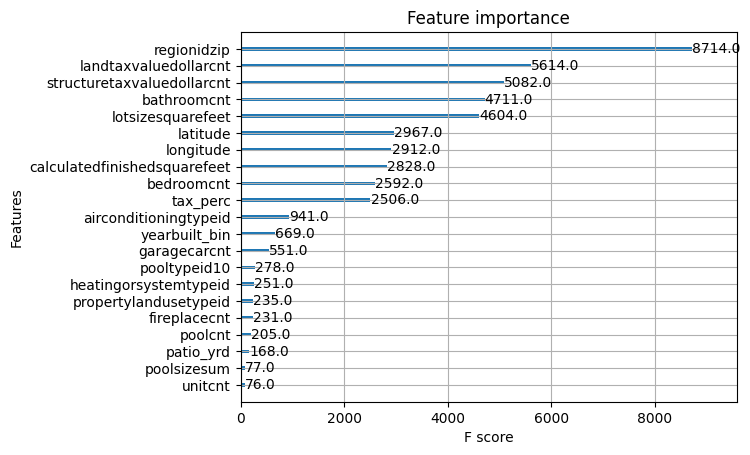

In [131]:
# Make predictions
y_pred = modelxgb.predict(X_test)

from sklearn.metrics import r2_score

# Evaluate the model using Mean Squared Error
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

# Optional: Visualize feature importance
import matplotlib.pyplot as plt
xgb.plot_importance(modelxgb)
plt.show()


An R-squared value of  0.695 means that approximately 69.5% of the variance in the target variable (house prices, in your case) is explained by the model. This indicates a decent model fit, but there's still about 30.5% of the variance that the model is not capturing.